In [1]:
# If you have issues with the below command, install shap and torch separately, before darts
# pip install "darts[torch]" matplotlib pandas numpy
# or use the provided requirments.txt

 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from darts import TimeSeries, concatenate
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.utils.likelihood_models import QuantileRegression
from darts.explainability import TFTExplainer
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.loggers import CSVLogger
from darts.metrics import mae, rmse, mql
from IPython.display import clear_output
import torch

In [2]:
SEED=42
warnings.filterwarnings("ignore")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Normally you would have to also set torch.use_deterministic_algorithms() to True
# But this harms the computing performance, so we opted not to due to computing constraints

In [3]:
torch.set_float32_matmul_precision('medium') #trade precision for some performance

In [4]:
DATA_PATH = "hour.csv"
QUANTILES = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
 

# The raw file drops hours that had zero recorded rentals, so the series is not
# continuous. Darts needs a fixed frequency, so we reindex onto a complete hourly
# grid and fill the gaps.
 
df = pd.read_csv(DATA_PATH)
data=df.copy()
df["dt"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")
df = df.set_index("dt").sort_index()
 
full_index = pd.date_range(df.index.min(), df.index.max(), freq="h")
n_missing = len(full_index) - len(df)
df = df.reindex(full_index)


In [5]:
df["cnt"] = df["cnt"].fillna(0.0)
for col in ["temp", "atemp", "hum", "windspeed"]:
    df[col] = df[col].interpolate("time").ffill().bfill()
for col in ["weathersit", "holiday", "workingday"]:
    df[col] = df[col].ffill().bfill()
 
df["hr"] = df.index.hour
df["weekday"] = df.index.dayofweek
df["mnth"] = df.index.month

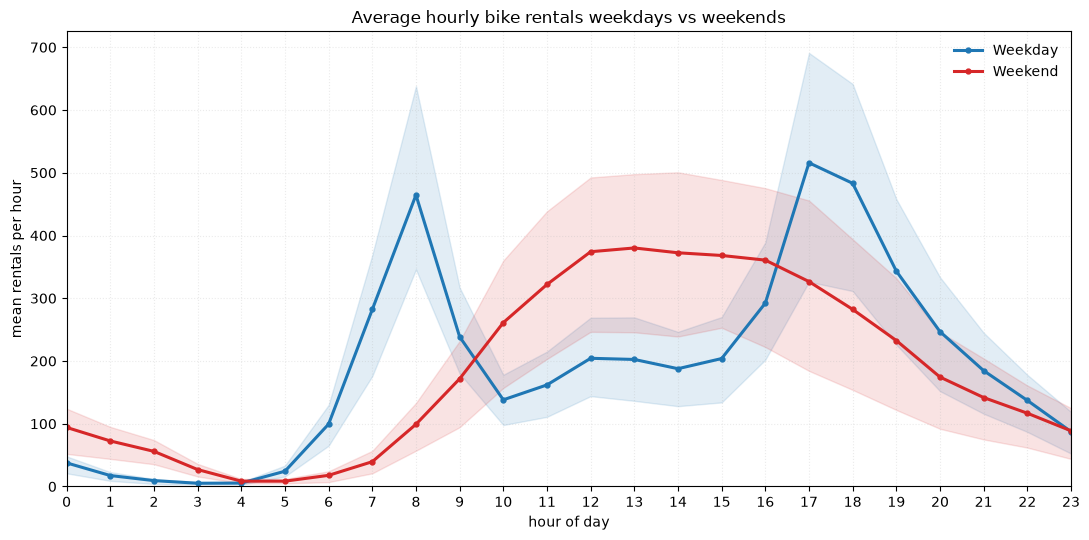

Weekday: 192 avg rentals
Weekend: 184 avg rentals


In [6]:
data["dt"] = pd.to_datetime(data["dteday"]) + pd.to_timedelta(data["hr"], unit="h")
data["hour"] = data["dt"].dt.hour
data["daytype"] = ["Weekend" if d >= 5 else "Weekday" for d in data["dt"].dt.dayofweek]

colors = {"Weekday": "#1f77b4", "Weekend": "#d62728"}
fig, ax = plt.subplots(figsize=(11, 5.5))

for label in ["Weekday", "Weekend"]:
    counts = data.loc[data["daytype"] == label].groupby("hour")["cnt"]
    mean = counts.mean()
    ax.plot(mean.index, mean.values, label=label, color=colors[label], lw=2.2, marker="o", ms=3.5)
    ax.fill_between(mean.index, counts.quantile(0.25), counts.quantile(0.75),
                    color=colors[label], alpha=0.13)

ax.set_xlabel("hour of day")
ax.set_ylabel("mean rentals per hour")
ax.set_title("Average hourly bike rentals weekdays vs weekends")
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("fig_hourly_profile.png", dpi=150)
plt.show()

for label in ["Weekday", "Weekend"]:
    sub_segment = data.loc[data["daytype"] == label]["cnt"]
    print(f'{label}: {sub_segment.mean():.0f} avg rentals')

del data

In [7]:
target = TimeSeries.from_series(df["cnt"], freq="h").astype(np.float32)
 
# Past covariates: observed weather*
weather_cols = ["temp", "atemp", "hum", "windspeed", "weathersit"]
past_cov = TimeSeries.from_dataframe(df, value_cols=weather_cols, freq="h").astype(np.float32)
 
# Future covariates: cyclic encodings and specific flags.
# Cyclic encodings for the periodic features
cyc_hour = datetime_attribute_timeseries(target, attribute="hour", cyclic=True)
cyc_dow = datetime_attribute_timeseries(target, attribute="day_of_week", cyclic=True)
cyc_month = datetime_attribute_timeseries(target, attribute="month", cyclic=True)

# holiday & workingday flags
flags = TimeSeries.from_dataframe(
    df, value_cols=["holiday", "workingday"], freq="h"
).astype(np.float32)
 
future_cov = concatenate(
    [cyc_hour, cyc_dow, cyc_month, flags], axis="component"
).astype(np.float32)
 
print("target     :", target.n_timesteps, "steps")
print("past_cov   :", past_cov.components.tolist())
print("future_cov :", future_cov.components.tolist())


target     : 17544 steps
past_cov   : ['temp', 'atemp', 'hum', 'windspeed', 'weathersit']
future_cov : ['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'holiday', 'workingday']


\*The reason I settled on weather as a past covariate only is due to the fact that it is *observed* weather not forecasted weather. In a realistic scenario, we will never have access to forecasted weather that ends up (consistently) to be accurate to the actually observed weather.

In [8]:
TRAIN_END = pd.Timestamp("2012-07-01")   # train:  2011.01.01 → 2012.06.30 (18 mo)
VAL_END   = pd.Timestamp("2012-10-01")   # val:    2012.07.01 → 2012.09.30 (3 mo)
                                          # test:   2012.10.01 → 2012.12.31 (3 mo)
train_target, rest = target.split_before(TRAIN_END)
val_target, test_target = rest.split_before(VAL_END)


In [9]:
target_scaler = Scaler()
train_target_s = target_scaler.fit_transform(train_target)
val_target_s = target_scaler.transform(val_target)
test_target_s = target_scaler.transform(test_target)
target_s = target_scaler.transform(target)

In [10]:
# We scale the past covariates only, as the future covariates are already normalized
past_scaler = Scaler()
past_scaler.fit(past_cov.slice_intersect(train_target))
past_cov_s = past_scaler.transform(past_cov)

In [11]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    mode='min'
)
logger = CSVLogger("tft_logs", name='tft_bikes_forecast')


In [12]:
model = TFTModel(
    input_chunk_length=168, #one week of context
    output_chunk_length=24, #forecast a full day
    hidden_size=32,
    lstm_layers=1,
    num_attention_heads=4,
    dropout=0.1,
    batch_size=128,
    n_epochs=100,
    add_relative_index=False,       # when no future covariates exist, set these to false
                                    # but the default is fine for us
    add_encoders=None,
    likelihood=QuantileRegression(quantiles=QUANTILES),
    random_state=SEED,
    pl_trainer_kwargs={"accelerator": "auto", 'callbacks': [early_stopping],
    'logger': logger}, #progress bar disabled due to the multitude of prediction/explainer calls below
    model_name="tft_bikeshare",
    force_reset=True,
    save_checkpoints=True,
)

In [13]:
model.fit(
    series=train_target_s,
    past_covariates=past_cov_s,
    future_covariates=future_cov,
    val_series=val_target_s,
    val_past_covariates=past_cov_s,
    val_future_covariates=future_cov,
    verbose=True,
)
model = TFTModel.load_from_checkpoint("tft_bikeshare", best=True)
model.save('tft_bikeshare_best')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 15.3 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 8.2 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 4.3 K  | train
7  | static_cont

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

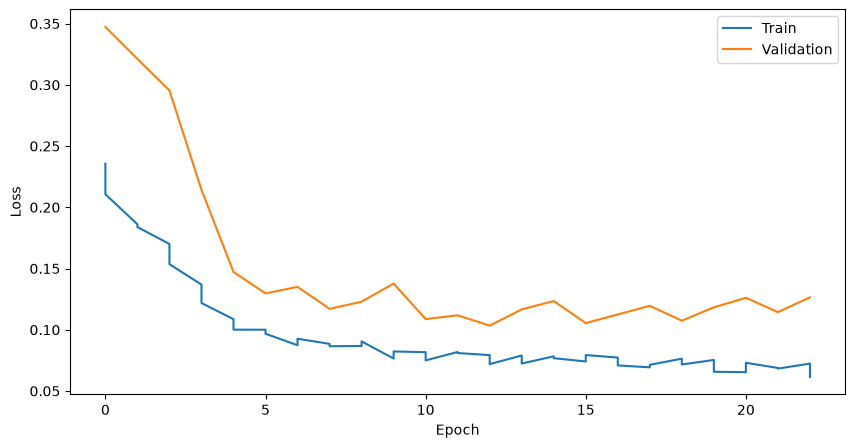

In [14]:
metrics = pd.read_csv("tft_logs/tft_bikes_forecast/version_0/metrics.csv")

train = metrics.dropna(subset=["train_loss"])
val = metrics.dropna(subset=["val_loss"])

plt.figure(figsize=(10, 5))
plt.plot(train["epoch"], train["train_loss"], label="Train")
plt.plot(val["epoch"], val["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
# Rolling 24h forecasts, without retraining.
hist_fc_s = model.historical_forecasts(
    series=target_s,
    past_covariates=past_cov_s,
    future_covariates=future_cov,
    start=VAL_END,
    forecast_horizon=24,
    stride=24,
    retrain=False,
    num_samples=500,          # probabilistic forecasting
    last_points_only=False,
    verbose=True,
)
hist_fc = target_scaler.inverse_transform(
    concatenate(hist_fc_s, axis="time") if isinstance(hist_fc_s, list) else hist_fc_s
)
test_eval = test_target.slice_intersect(hist_fc)
hist_fc = hist_fc.slice_intersect(test_eval)
 
print("\n--- TEST-set accuracy (median forecast), Oct-Dec 2012 ---")
print(f"MAE  : {mae(test_eval, hist_fc):.1f} rentals")
print(f"RMSE : {rmse(test_eval, hist_fc):.1f} rentals")
print(f"Mean quantile loss (0.05/0.1/0.5/0.9/0.95): "
    f"{mql(test_eval, hist_fc, q=0.05):.2f}  / "
    f"{mql(test_eval, hist_fc, q=0.1):.2f}  / "
    f"{mql(test_eval, hist_fc, q=0.5):.2f}  / "
    f"{mql(test_eval, hist_fc, q=0.9):.2f}  /"
    f"{mql(test_eval, hist_fc, q=0.95):.2f}")
    

Dataset output has a different data type than the dataset the model was trained on; current data type: float32, expected data type: float32. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/92 [00:00<?, ?it/s]


--- TEST-set accuracy (median forecast), Oct-Dec 2012 ---
MAE  : 51.2 rentals
RMSE : 83.6 rentals
Mean quantile loss (0.05/0.1/0.5/0.9/0.95): 18.79  / 29.19  / 51.22  / 23.71  /14.41


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

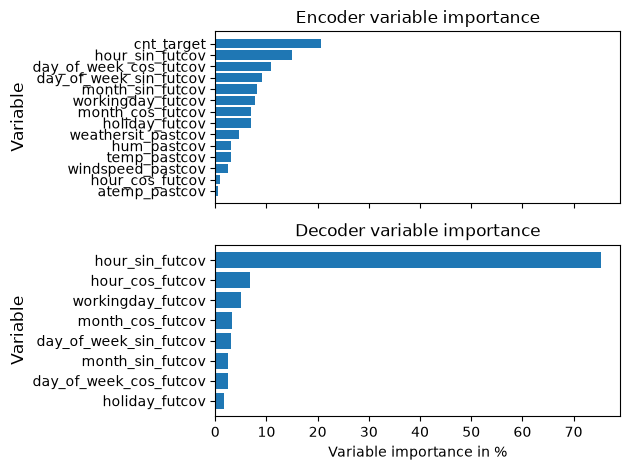

<Figure size 640x480 with 0 Axes>

Encoder (past) importance:
    atemp_pastcov  hour_cos_futcov  windspeed_pastcov  temp_pastcov  \
0            0.5              1.0                2.4           3.1   

   hum_pastcov  weathersit_pastcov  holiday_futcov  month_cos_futcov  \
0          3.1                 4.6             6.9               6.9   

   workingday_futcov  month_sin_futcov  day_of_week_sin_futcov  \
0                7.7               8.1                9.099999   

   day_of_week_cos_futcov  hour_sin_futcov  cnt_target  
0                    10.9        15.000001   20.700001  
Decoder (future) importance:
    holiday_futcov  day_of_week_cos_futcov  month_sin_futcov  \
0             1.8                     2.5               2.5   

   day_of_week_sin_futcov  month_cos_futcov  workingday_futcov  \
0                     3.0               3.2                5.0   

   hour_cos_futcov  hour_sin_futcov  
0              6.7        75.300003  


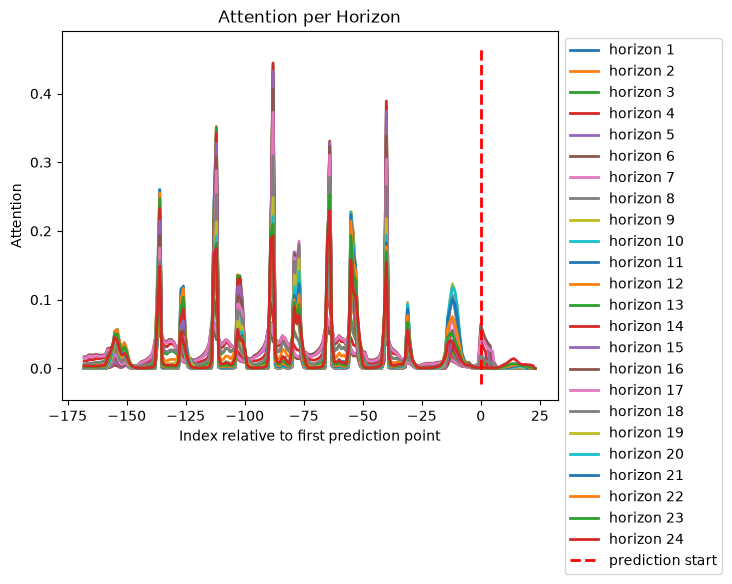

<Figure size 640x480 with 0 Axes>

In [16]:

explainer = TFTExplainer(model)

explainability_result = explainer.explain()
 
# Variable importance (encoder = past inputs, decoder = future inputs)
explainer.plot_variable_selection(explainability_result)
plt.tight_layout()
plt.savefig("fig_variable_selection.png", dpi=150, bbox_inches="tight")
plt.show()
 
importances = explainability_result.get_feature_importances()
print("Encoder (past) importance:\n", importances["encoder_importance"])
print("Decoder (future) importance:\n", importances["decoder_importance"])
 
# Attention over time
explainer.plot_attention(explainability_result, plot_type="all")
plt.tight_layout()
plt.savefig("fig_attention.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
att = explainability_result.get_attention()

print(att)
print(att.shape)

mean_att = att.mean(axis=1).values().flatten()
idx = mean_att.argsort()[::-1][:8]
print("top attention lags (hours relative to prediction start):", sorted(idx - 168))


                     horizon 1  horizon 2  horizon 3  horizon 4  horizon 5  ...  horizon 20  horizon 21  horizon 22  horizon 23  horizon 24
2012-06-24 00:00:00   0.001864   0.002944   0.005930   0.010636   0.014939  ...    0.000586    0.001157    0.002078    0.002993    0.003721
2012-06-24 01:00:00   0.001654   0.002768   0.005754   0.010430   0.014727  ...    0.000473    0.000963    0.001774    0.002597    0.003257
2012-06-24 02:00:00   0.002072   0.003593   0.007416   0.013050   0.017836  ...    0.000499    0.001001    0.001851    0.002782    0.003666
2012-06-24 03:00:00   0.001872   0.003376   0.007165   0.012798   0.017627  ...    0.000443    0.000898    0.001668    0.002503    0.003304
2012-06-24 04:00:00   0.001803   0.003330   0.007113   0.012660   0.017335  ...    0.000421    0.000844    0.001555    0.002327    0.003098
...                        ...        ...        ...        ...        ...  ...         ...         ...         ...         ...         ...
2012-07-01 19:00:00 

stable top lags (hours): [-160, -136, -112, -88, -64, -40, -17, -16]


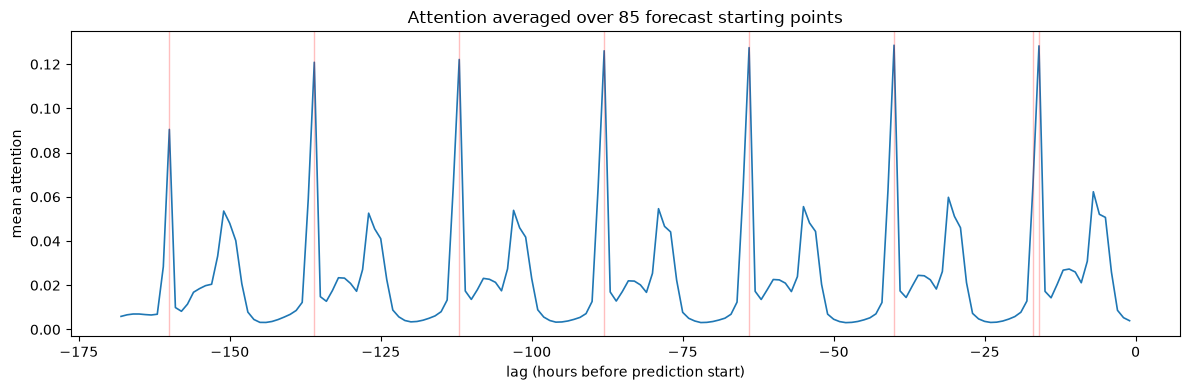

In [18]:
acc = np.zeros(168)
n = 0
# daily forecast for every 
for start in pd.date_range(TRAIN_END + pd.Timedelta(days=8), VAL_END, freq="1D"):
    ctx = target_s.drop_after(start)
    res = explainer.explain(
        foreground_series=ctx[-168:],
        foreground_past_covariates=past_cov_s,
        foreground_future_covariates=future_cov,
    )
    a = res.get_attention().mean(axis=1).values().flatten()[:168]
    acc += a
    n += 1
    clear_output()

mean_att = acc / n
lags = np.arange(-168, 0) # encoder positions as lags
top = np.sort(np.argsort(mean_att)[::-1][:8] - 168)
print(f"stable top lags (hours): {top.tolist()}")
 
plt.figure(figsize=(12, 4))
plt.plot(lags, mean_att, lw=1.2)
for t in top:
    plt.axvline(t, color="red", alpha=0.25, lw=1)
plt.xlabel("lag (hours before prediction start)")
plt.ylabel("mean attention")
plt.title(f"Attention averaged over {n} forecast starting points")
plt.tight_layout()
plt.savefig("fig_attention_averaged.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
print_statements=[]
for start_hour in [0, 6, 12, 18]:
    acc_h = np.zeros(168)
    n_h = 0
    forecast_starts = pd.date_range(TRAIN_END + pd.Timedelta(days=8), VAL_END, freq="1D")
    forecast_starts = forecast_starts + pd.Timedelta(hours=start_hour)
    for start in forecast_starts:
        if start >= VAL_END:
            continue
        ctx = target_s.drop_after(start)
        res = explainer.explain(
            foreground_series=ctx[-168:],
            foreground_past_covariates=past_cov_s,
            foreground_future_covariates=future_cov,
            
        )
        clear_output()
        acc_h += res.get_attention().mean(axis=1).values().flatten()[:168]
        n_h += 1
    top_h = np.sort(np.argsort(acc_h / n_h)[::-1][:8] - 168)
    clock = [(start_hour + int(t)) % 24 for t in top_h]
    print_statements.append(f"start {start_hour:02d}:00 -> lags {top_h.tolist()}  clock hours {sorted(set(clock))}")

for print_statement in print_statements:
    print(f'\n {print_statement}')



 start 00:00 -> lags [-160, -136, -112, -88, -64, -40, -17, -16]  clock hours [7, 8]

 start 06:00 -> lags [-166, -142, -118, -94, -70, -46, -23, -22]  clock hours [7, 8]

 start 12:00 -> lags [-148, -124, -100, -76, -52, -28, -5, -4]  clock hours [7, 8]

 start 18:00 -> lags [-167, -154, -130, -106, -82, -58, -34, -10]  clock hours [8, 19]


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
Dataset output has a different data type than the dataset the model was trained on; current data type: float32, expected data type: float32. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

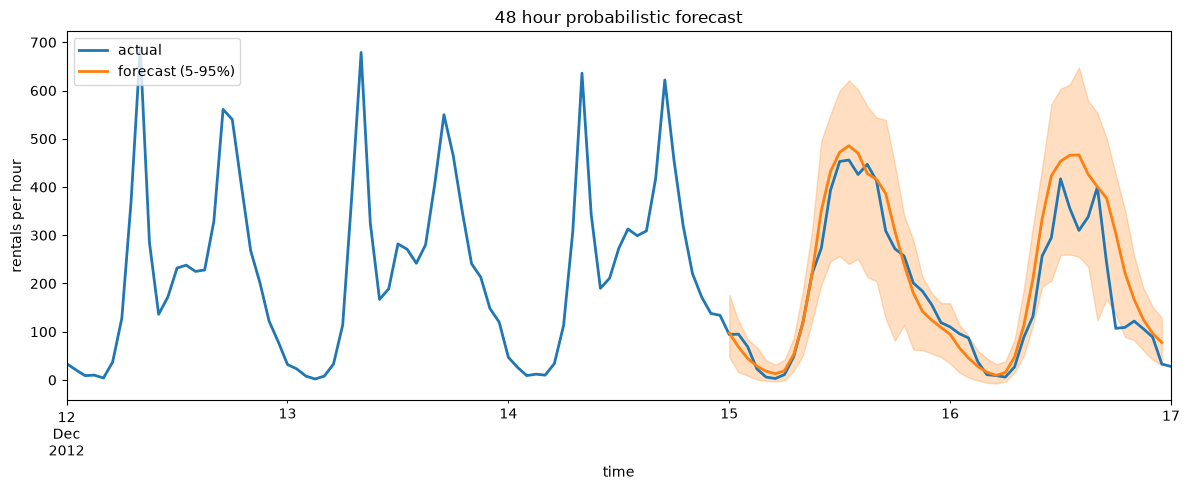

In [20]:
#Forecast one day and plot the 5-95% band around the median.
context_end = pd.Timestamp("2012-12-15")
pred = model.predict(
    n=48,
    series=target_s.drop_after(context_end),
    past_covariates=past_cov_s,
    future_covariates=future_cov,
    num_samples=500,
)
pred = target_scaler.inverse_transform(pred)
actual_window = target.slice(context_end - pd.Timedelta(hours=72),
                             context_end + pd.Timedelta(hours=48))
 
plt.figure(figsize=(12, 5))
actual_window.plot(label="actual")
pred.plot(low_quantile=0.05, high_quantile=0.95, label="forecast (5-95%)")
plt.title("48 hour probabilistic forecast")
plt.ylabel("rentals per hour")
plt.tight_layout()
plt.savefig("fig_quantile_forecast.png", dpi=150, bbox_inches="tight")
plt.show()


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
Dataset output has a different data type than the dataset the model was trained on; current data type: float32, expected data type: float32. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

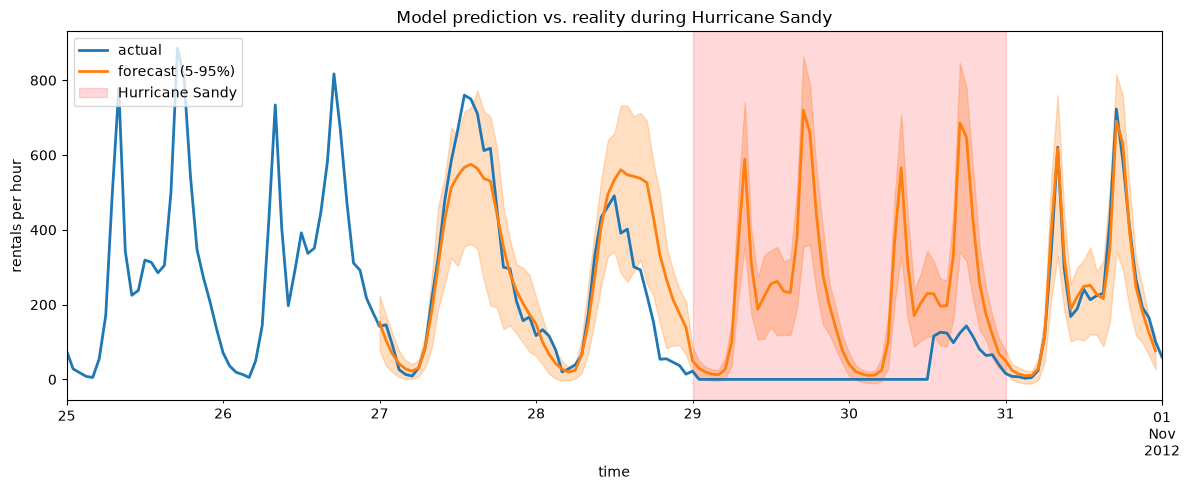

In [21]:
sandy_start = pd.Timestamp("2012-10-27")
sandy_ctx = target_s.drop_after(sandy_start)
sandy_pred = model.predict(
    n=24 * 5,
    series=sandy_ctx,
    past_covariates=past_cov_s,
    future_covariates=future_cov,
    num_samples=500,
)




sandy_pred = target_scaler.inverse_transform(sandy_pred)
sandy_actual = target.slice(sandy_start - pd.Timedelta(days=2),
                            sandy_start + pd.Timedelta(days=5))



plt.figure(figsize=(12, 5))
sandy_actual.plot(label="actual")
sandy_pred.plot(low_quantile=0.05, high_quantile=0.95, label="forecast (5-95%)")
plt.axvspan(pd.Timestamp("2012-10-29"), pd.Timestamp("2012-10-31"),
            alpha=0.15, color="red", label="Hurricane Sandy")
plt.title("Model prediction vs. reality during Hurricane Sandy")
plt.ylabel("rentals per hour")
plt.legend()
plt.tight_layout()
plt.savefig("fig_sandy_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()